In [1]:
import pandas as pd
import yfinance as yf

# Step 1: Getting all required Data
- Download relevant Data of stocks in the ASX 50 using Yahoo Finance
    - Get 5 Year data or whatever is the Maximum data we can get
    - Also wanted the Top 10 ETF in betashares, the top 10 was choosen by Claude, not using any maths or calculations

In [2]:
ticker_list = [
    "BHP.AX", "CBA.AX", "CSL.AX", "NAB.AX", "WBC.AX",
    "ANZ.AX", "WES.AX", "MQG.AX", "WOW.AX", "GMG.AX",
    "TLS.AX", "RIO.AX", "TCL.AX", "ALL.AX", "COL.AX",
    "AMC.AX", "QBE.AX", "SUN.AX", "IAG.AX", "ORG.AX",
    "APA.AX", "BXB.AX", "SGP.AX", "GPT.AX", "VCX.AX",
    "SCG.AX", "MPL.AX", "CPU.AX", "ASX.AX", "SEK.AX",
    "CAR.AX", "REA.AX", "XRO.AX", "COH.AX", "RMD.AX",
    "FPH.AX", "SHL.AX", "STO.AX", "WDS.AX", "S32.AX",
    "MIN.AX", "ILU.AX", "LYC.AX", "SOL.AX", "NST.AX",
    "EVN.AX", "QAN.AX", "A2M.AX", "PME.AX", "ARB.AX"
]

In [3]:
ticker_list[:5]  # Display the first 5 tickers to verify the format

['BHP.AX', 'CBA.AX', 'CSL.AX', 'NAB.AX', 'WBC.AX']

In [4]:
len(ticker_list)  # Check the total number of tickers

50

In [5]:
import os

for ticker in ticker_list:
    if not os.path.exists(f"stock_data/{ticker}_data.csv"):
        try:
            print(f"Downloading data for {ticker}...")
            data = yf.download(ticker, period="5y", interval="1d")
            data = data[["Close", "Volume"]]
            data.to_csv(f"stock_data/{ticker}_data.csv")
            print(f"Data for {ticker} saved to stock_data/{ticker}_data.csv")
        except Exception as e:
            print(f"Error downloading data for {ticker}: {e}")

In [6]:
etf_list = [
    "A200.AX",   # 1. Australia 200 ETF              — AUM: $9.70B
    "NDQ.AX",    # 2. Nasdaq 100 ETF                 — AUM: $7.27B
    "AAA.AX",    # 3. Australian High Interest Cash   — AUM: $5.13B
    "BGBL.AX",   # 4. Global Shares ETF               — AUM: $3.73B
    "ETHI.AX",   # 5. Global Sustainability Leaders   — AUM: $3.48B
    "HBRD.AX",   # 6. Australian High Interest Bond   — AUM: $2.51B
    "HGBL.AX",   # 7. Global Shares Currency Hedged   — AUM: $2.30B
    "QPON.AX",   # 8. Bank Senior Floating Rate Bond  — AUM: $1.95B
    "CRED.AX",   # 9. Investment Grade Corporate Bond — AUM: $1.77B
    "QAU.AX",    # 10. Gold Bullion Currency Hedged   — AUM: $1.54B
]


for etf in etf_list:
    if not os.path.exists(f"stock_data/{etf}_data.csv"):
        try:
            print(f"Downloading data for {etf}...")
            data = yf.download(etf, period="5y", interval="1d")
            data = data[["Close", "Volume"]]
            data.to_csv(f"stock_data/{etf}_data.csv")
            print(f"Data for {etf} saved to stock_data/{etf}_data.csv")
        except Exception as e:
            print(f"Error downloading data for {etf}: {e}")

# Step 2: Get Log Returns of each tickers
- Make a returns matrix of each tickers, for every trading day
- Preprocess the data to handle missing values and etc.

In [7]:
import numpy as np
np.random.seed(42)  # For reproducibility

In [8]:
# Preprocess df because its weirdly formatted
def preprocess_data(file_path):
    # Skip first 2 rows
    df = pd.read_csv(file_path, skiprows=2)
    
    # Rename columns
    df.columns = ["Date", "Close", "Volume"]

    #Convert Date to datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Turn Close and Volumne into numeric
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")
    df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce") 
    return df

PREPROCESS = False  # Set to False if we already preprocessed
if PREPROCESS:
    for ticker in ticker_list+etf_list:
        file_path = f"stock_data/{ticker}_data.csv"
        try:
            df = preprocess_data(file_path)
            df.to_csv(f"stock_data/{ticker}_data.csv", index=False)
        except Exception as e:
            print(f"Error preprocessing data for {ticker}: {e}")


In [9]:
# Makes a Log return Data Frame
return_df = pd.DataFrame()

for ticker in [ticker_list, etf_list]:
    for symbol in ticker:
        try:
            data = pd.read_csv(f"stock_data/{symbol}_data.csv", index_col="Date", parse_dates=True)

            symbol = symbol.removesuffix(".AX")  # Remove .AX from symbol for cleaner column names

            data[f"{symbol}"] = np.log(data["Close"]).diff() # Diff to get daily returns

            data = data.iloc[1:]  # Drop the first row which will be NaN after diff

            # Add the return column to the return_df
            return_df = pd.concat([return_df, data[f"{symbol}"]], axis=1)
        except Exception as e:
            print(f"Error processing data for {symbol}: {e}")

In [10]:
return_df.head()

,BHP,CBA,CSL,NAB,WBC,ANZ,WES,MQG,WOW,GMG,...,A200,NDQ,AAA,BGBL,ETHI,HBRD,HGBL,QPON,CRED,QAU
2021-05-04,0.025195,0.008327,0.000959,0.000734,NaN,-0.009322,0.007226,0.000561,0.006135,0.007815,...,0.005050,-0.010807,-0.0001,NaN,-0.005106,0.000000,NaN,-0.001151,0.000371,0.006526
2021-05-05,0.010929,0.024787,0.023504,0.004394,NaN,-0.032790,0.000554,0.005165,0.003053,-0.003639,...,0.004356,-0.011956,0.0000,NaN,-0.005132,0.000000,NaN,-0.000384,0.000372,-0.004742
2021-05-06,0.021104,0.002370,-0.002777,-0.030041,0.002308,-0.009001,-0.006107,-0.013183,-0.002544,-0.001042,...,-0.004188,-0.006551,0.0000,NaN,-0.001717,-0.001945,NaN,0.000384,0.001112,0.007105
2021-05-07,0.005807,0.010489,-0.008633,0.008249,0.002687,0.003610,0.007213,-0.003465,0.004067,0.003124,...,0.002264,0.004142,0.0002,NaN,0.000859,0.001945,NaN,0.000000,0.001852,0.016384
2021-05-10,0.030669,0.013011,0.003092,0.011509,0.012569,0.012126,0.010815,-0.001516,0.027029,0.014960,...,0.012814,-0.003796,-0.0002,NaN,0.000000,-0.003895,NaN,-0.000384,-0.001852,0.009243


*Note*:\
Here we notice that are some incomplete Data, I understand this when downloading. However, now I notice that it would be difficult to fix, and filling in the missing data would cause errors and bias for high numbers of incompletion. 

So, I will be taking only data where there are $\le 5$% missing data, and from the remaining columns fill missing values based on mean returns

In [11]:
# Delete columns with more than 5% missing values
threshold = 0.05
col = return_df.isnull().sum()/len(return_df)<=threshold
return_df = return_df.loc[:, col]

In [12]:
for ticker, i in return_df.isnull().sum().items():
    if i > 0:
        print(ticker, i)

WBC 2
A200 1
AAA 1
HBRD 1
QPON 1
CRED 1
QAU 1


*Note*:\
Here we can conclude that there may just be errors in the data collection.

Therefore We will simply fill the missing values with 0, this won't affect the data too much considering only 1,2 data are missing in more than 1,000 data.

Another choice: Use ffill on original data, this would allow us to capture if they are too many consecutive missing values, however, we know that there are barely any missing values, and manually changing the original data takes too long.

In [13]:
return_df.fillna(0, inplace=True)

,BHP,CBA,CSL,NAB,WBC,ANZ,WES,MQG,WOW,GMG,...,PME,ARB,A200,NDQ,AAA,ETHI,HBRD,QPON,CRED,QAU
2021-05-04,0.025195,0.008327,0.000959,0.000734,0.000000,-0.009322,0.007226,0.000561,0.006135,0.007815,...,0.002355,-0.026051,0.005050,-0.010807,-0.000100,-0.005106,0.000000,-0.001151,0.000371,0.006526
2021-05-05,0.010929,0.024787,0.023504,0.004394,0.000000,-0.032790,0.000554,0.005165,0.003053,-0.003639,...,-0.019431,-0.004542,0.004356,-0.011956,0.000000,-0.005132,0.000000,-0.000384,0.000372,-0.004742
2021-05-06,0.021104,0.002370,-0.002777,-0.030041,0.002308,-0.009001,-0.006107,-0.013183,-0.002544,-0.001042,...,0.001743,0.003476,-0.004188,-0.006551,0.000000,-0.001717,-0.001945,0.000384,0.001112,0.007105
2021-05-07,0.005807,0.010489,-0.008633,0.008249,0.002687,0.003610,0.007213,-0.003465,0.004067,0.003124,...,-0.080877,0.001067,0.002264,0.004142,0.000200,0.000859,0.001945,0.000000,0.001852,0.016384
2021-05-10,0.030669,0.013011,0.003092,0.011509,0.012569,0.012126,0.010815,-0.001516,0.027029,0.014960,...,-0.019298,0.002663,0.012814,-0.003796,-0.000200,0.000000,-0.003895,-0.000384,-0.001852,0.009243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-27,0.001069,-0.008114,0.013903,0.002990,-0.000769,-0.008037,-0.004593,-0.001120,-0.005292,0.009563,...,-0.001592,0.000512,-0.002661,0.009115,0.000199,-0.003244,0.001982,0.000000,-0.001326,0.006165
2026-04-28,-0.013084,0.008801,-0.022401,-0.000747,-0.009278,0.002501,-0.021209,-0.000690,-0.005054,-0.017833,...,-0.015468,-0.019107,-0.005276,-0.004636,0.000000,-0.001951,-0.000991,0.000381,-0.001328,-0.015892
2026-04-29,-0.008697,-0.014015,-0.024503,-0.012525,-0.010411,0.004155,0.000415,0.005463,-0.005616,0.001383,...,-0.008566,-0.004703,-0.003717,-0.000179,0.000000,-0.004568,0.000991,-0.000761,0.002212,-0.009823
2026-04-30,-0.022638,0.008559,-0.011273,0.005280,0.007299,0.012907,0.007986,0.008330,-0.080959,0.021874,...,-0.003268,-0.026003,-0.002002,0.003034,0.000398,-0.001309,-0.000991,0.000000,-0.004429,-0.006051


# Step 3: Get mean, cov, plot correlation (EDA)

In [14]:
good_ticker = return_df.columns

In [15]:
# mean and covariance of returns
mu = return_df.mean()*252
cov = return_df.cov()*252

# Correlation matrix
corr = return_df.corr()

In [16]:
corr.head()

,BHP,CBA,CSL,NAB,WBC,ANZ,WES,MQG,WOW,GMG,...,PME,ARB,A200,NDQ,AAA,ETHI,HBRD,QPON,CRED,QAU
BHP,1.000000,0.172993,0.055478,0.183453,0.200446,0.242697,0.153377,0.312027,0.114362,0.189087,...,0.076743,0.185123,0.594966,0.210674,0.017357,0.228123,0.055724,0.066446,0.055344,0.251687
CBA,0.172993,1.000000,0.209543,0.705587,0.688563,0.633439,0.453893,0.455241,0.243323,0.333420,...,0.190738,0.285966,0.655766,0.303630,0.037118,0.351622,0.091579,0.068569,0.114176,0.042509
CSL,0.055478,0.209543,1.000000,0.185105,0.201724,0.179829,0.241595,0.286398,0.196880,0.305252,...,0.287998,0.214280,0.398569,0.294523,0.017505,0.321401,0.045063,0.028421,0.156133,0.022367
NAB,0.183453,0.705587,0.185105,1.000000,0.765092,0.699527,0.433801,0.499068,0.232357,0.328778,...,0.197735,0.305098,0.657112,0.350258,0.015765,0.403863,0.113647,0.091909,0.115402,0.029620
WBC,0.200446,0.688563,0.201724,0.765092,1.000000,0.734579,0.412121,0.481944,0.198949,0.300317,...,0.202193,0.272624,0.649944,0.316280,0.044990,0.393356,0.112471,0.072480,0.120954,0.032651


# Step 4: EDA
- Create a heatmap using the randomised order
- Create a clustered heatmap
    - Run Vat algorithm
    - Then plot normally
Verify that certain sector, have a cluster

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\benke\AppData\Local\Temp\ipykernel_19152\1827690352.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


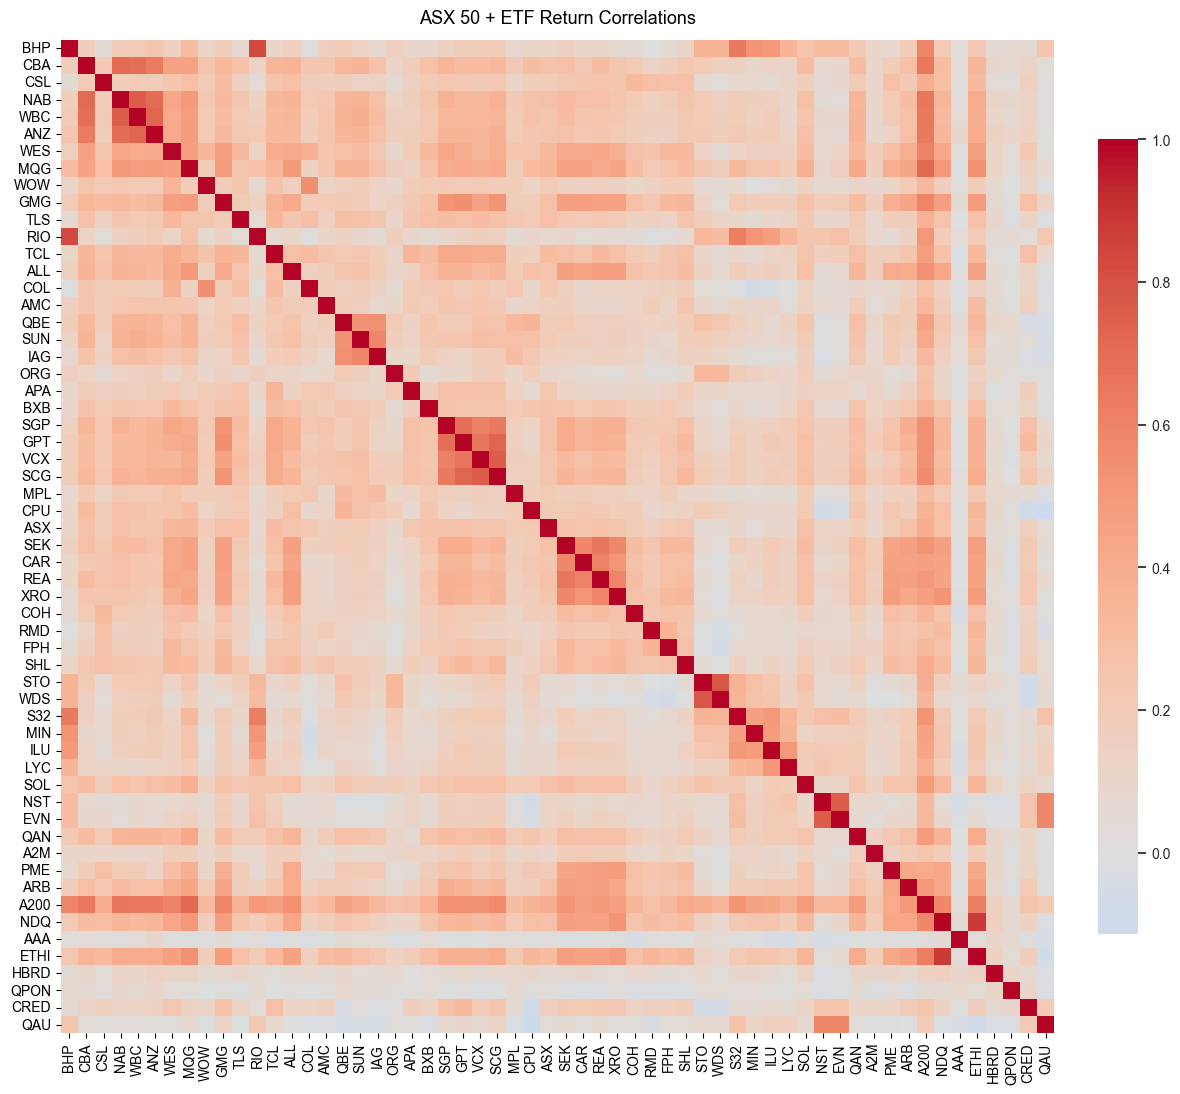

In [18]:
fig, ax = plt.subplots(figsize=(12,11))

sns.set_theme(font_scale=0.7) # Scales all plot text
g = sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, fmt=".2f", linewidths=0, ax=ax, 
                square=True, cbar_kws={"shrink": 0.8, "fraction": 0.046, "pad": 0.04})
ax.set_title("ASX 50 + ETF Return Correlations", fontsize=13, pad=12)

g.collections[0].colorbar.ax.tick_params(labelsize=10)
fig.tight_layout()
fig.show()
fig.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

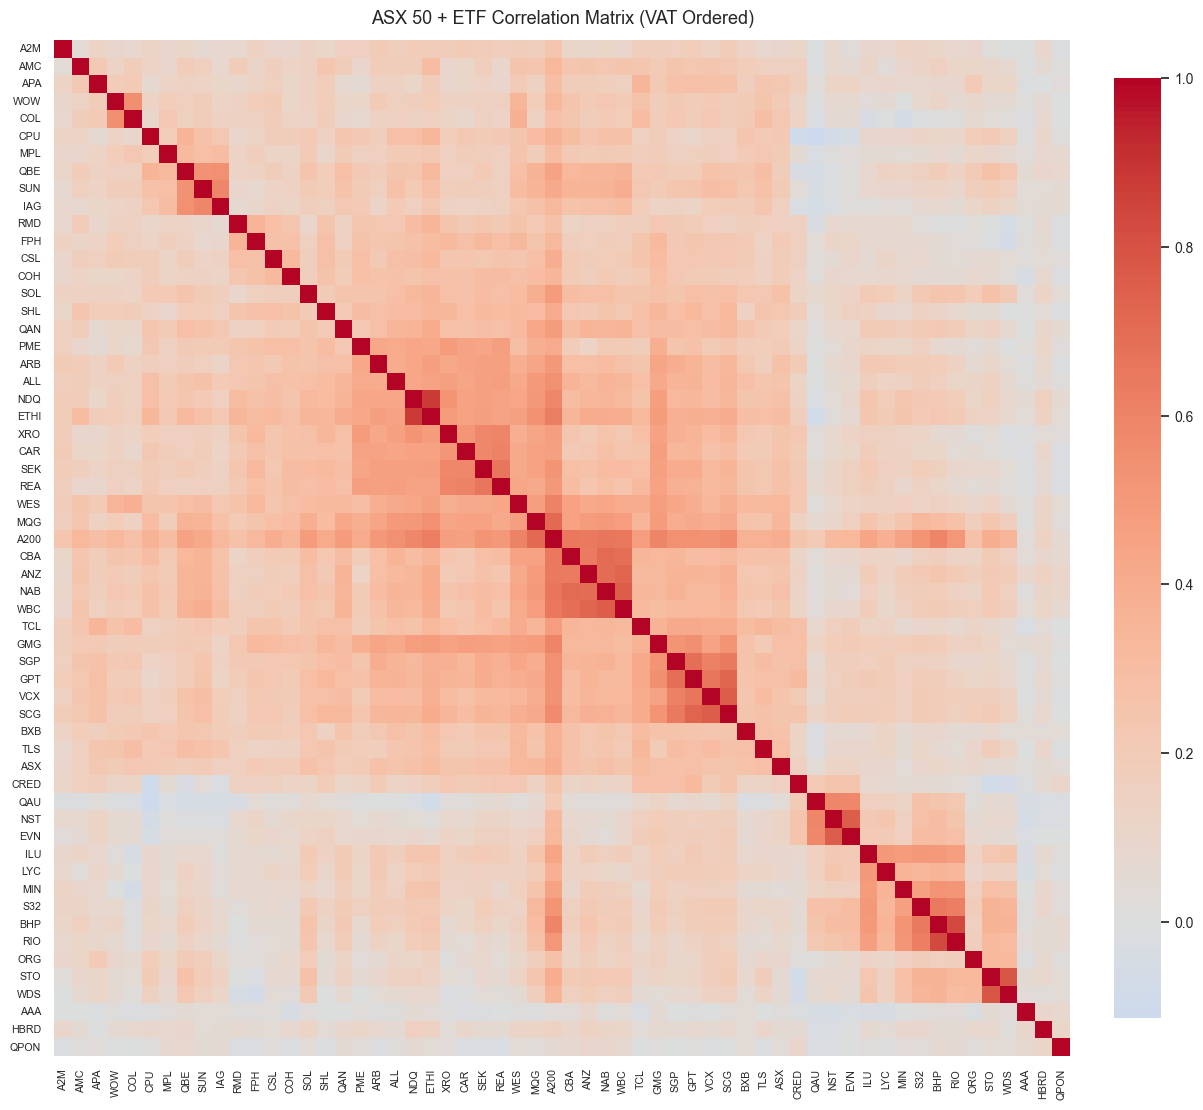

In [19]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# step 1 — convert correlation to distance
# high correlation = low distance
distance = 1 - corr

# step 2 — hierarchical clustering on the distance matrix
linked = linkage(squareform(distance), method="average")

# step 3 — get the optimal leaf order
order = leaves_list(linked)

# step 4 — reorder the correlation matrix
corr_vat = corr.iloc[order, order]

# step 5 — plot as normal heatmap
fig, ax = plt.subplots(figsize=(12, 12))

sns.set_theme(font_scale=0.5)
g = sns.heatmap(corr_vat, cmap="coolwarm", center=0, annot=False,
                linewidths=0, ax=ax, square=True,
                cbar_kws={"shrink": 0.8, "fraction": 0.046, "pad": 0.04})

g.collections[0].colorbar.ax.tick_params(labelsize=10)
ax.set_title("ASX 50 + ETF Correlation Matrix (VAT Ordered)", fontsize=13, pad=12)

plt.tight_layout()
fig.savefig("correlation_heatmap_vat.png", dpi=300, bbox_inches="tight")
plt.show()

*Note*:\
Financials — CBA, NAB, WBC, ANZ, MQG\
Materials — BHP, RIO, FMG, S32, MIN\
REITs — DXS, GPT, MGR, SGP, VCX\
ETFs/Diversifiers — QAU, AAA, HBRD low correlation with everything\

Notice sectors of the same Group have a cluster, while ETFs have a low correlation with any other.

However, overall the correlation between any stocks on average are relatively low, showcasing that diversifing would considerably reduce the risk.

# Step 5: Plot efficient frontier
- Get random weights of portfolios
    - Get mean and var of each portfolio
- Plot each portfolio's risk and return
- Find Max Sharpe Ratio

Formula used:\
$\mu_p^ = \sum_{i=1}^{n} w_i\mu_i$\
$\sigma_p^2 = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j \sigma_{ij}$ = $\sigma_p^2 = w\cdot (\rho\times w)$


In [20]:
def port_return(weights):
    # Calculate the expected return of a portfolio given weights and mean returns
    # The means are annualized
    return np.dot(weights, mu)

def port_std(weights):
    # Calculate the standard deviation of a portfolio given weights and covariance matrix
    # The covariance is annualized
    return np.sqrt(np.dot(weights, np.dot(cov, weights)))

In [21]:
def weights_maker(col, alpha):
    # Generate random weights for the assets in the portfolio
    # Make sure no single stock has more than 20% allocation to avoid overconcentration
    w = np.random.dirichlet(np.ones(len(col)) * alpha)
    w = np.clip(w, 0, 0.2)   # max 20% per stock
    w /= w.sum()
    return w

*Note*:\
Iter 100,000 times, with 80 percent with more uneven porfolio, and 20 percent more diversified.

In [22]:
# Using 100000 random iterations 
n = 100000
returns = []
stds = []
w = []

for i in range(n):
    alpha = 0.4 if i<n*0.8 else 5 #displays difference between more and less concentrated portfolios
    weights = weights_maker(return_df.columns, alpha=alpha)
    w.append(weights)
    returns.append(port_return(weights))
    stds.append(port_std(weights))


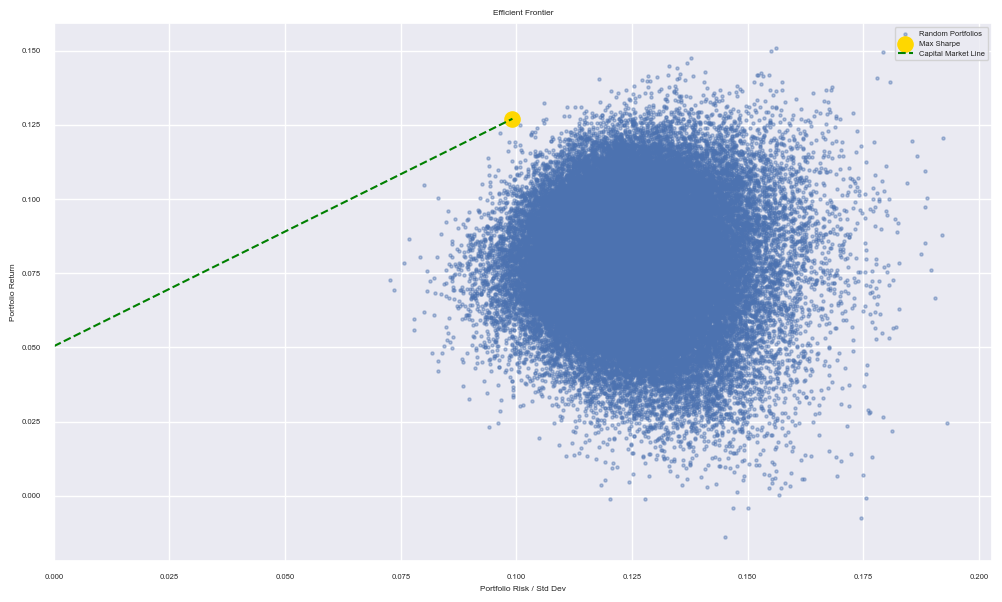

In [23]:
results_df = pd.DataFrame({
    "risk": stds,
    "return": returns
})

# Max Sharpe portfolio
rf = 0.0504  # risk-free rate in Australia
results_df["sharpe"] = (results_df["return"] - rf) / results_df["risk"]
max_sharpe_idx = results_df["sharpe"].idxmax()
max_sharpe = results_df.loc[max_sharpe_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(results_df["risk"], results_df["return"], s=5, alpha=0.4, label="Random Portfolios")

ax.scatter(
    max_sharpe["risk"],
    max_sharpe["return"],
    color="gold",
    s=120,
    label="Max Sharpe"
)

# Capital Market Line
x = np.array([0, max_sharpe["risk"]])
y = rf + (max_sharpe["sharpe"]) * x

ax.plot(x, y, linestyle="--", color="green", label="Capital Market Line")

ax.set_xlabel("Portfolio Risk / Std Dev")
ax.set_ylabel("Portfolio Return")
ax.set_title("Efficient Frontier")
ax.legend()
ax.set_xlim(0)

fig.tight_layout()
fig.savefig("efficient_frontier.png", dpi=300, bbox_inches="tight")

The efficient frontier here are clustered, there aren't a wide variety of standard deviations here. \
This is mainly because we picked a wide variety of stocks, \
therefore, when generating a random portfolio, we are immediately diversified, \
so, all our generated portfolio fall within simillar standard deviations so subsequently it's mean.

# Result

In [24]:
print(f"Max Sharpe ratio: {max_sharpe["sharpe"]:.2f}")
print(f"Return: {returns[max_sharpe_idx]:.2%}")
print(f"Std:    {stds[max_sharpe_idx]:.2%}")
print(f"Weights:\n{pd.Series(w[max_sharpe_idx], index=return_df.columns).sort_values(ascending=False).head(10)}")

Max Sharpe ratio: 0.77
Return: 12.71%
Std:    9.92%
Weights:
BXB     0.166440
QAU     0.153880
IAG     0.093048
AMC     0.063817
ORG     0.049017
QPON    0.043439
TLS     0.043365
NAB     0.039753
CAR     0.036679
CPU     0.029483
dtype: float64
